<a href="https://colab.research.google.com/github/RifkyRiansyahTR2/simulasi-model-ising-2d/blob/main/Case1_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

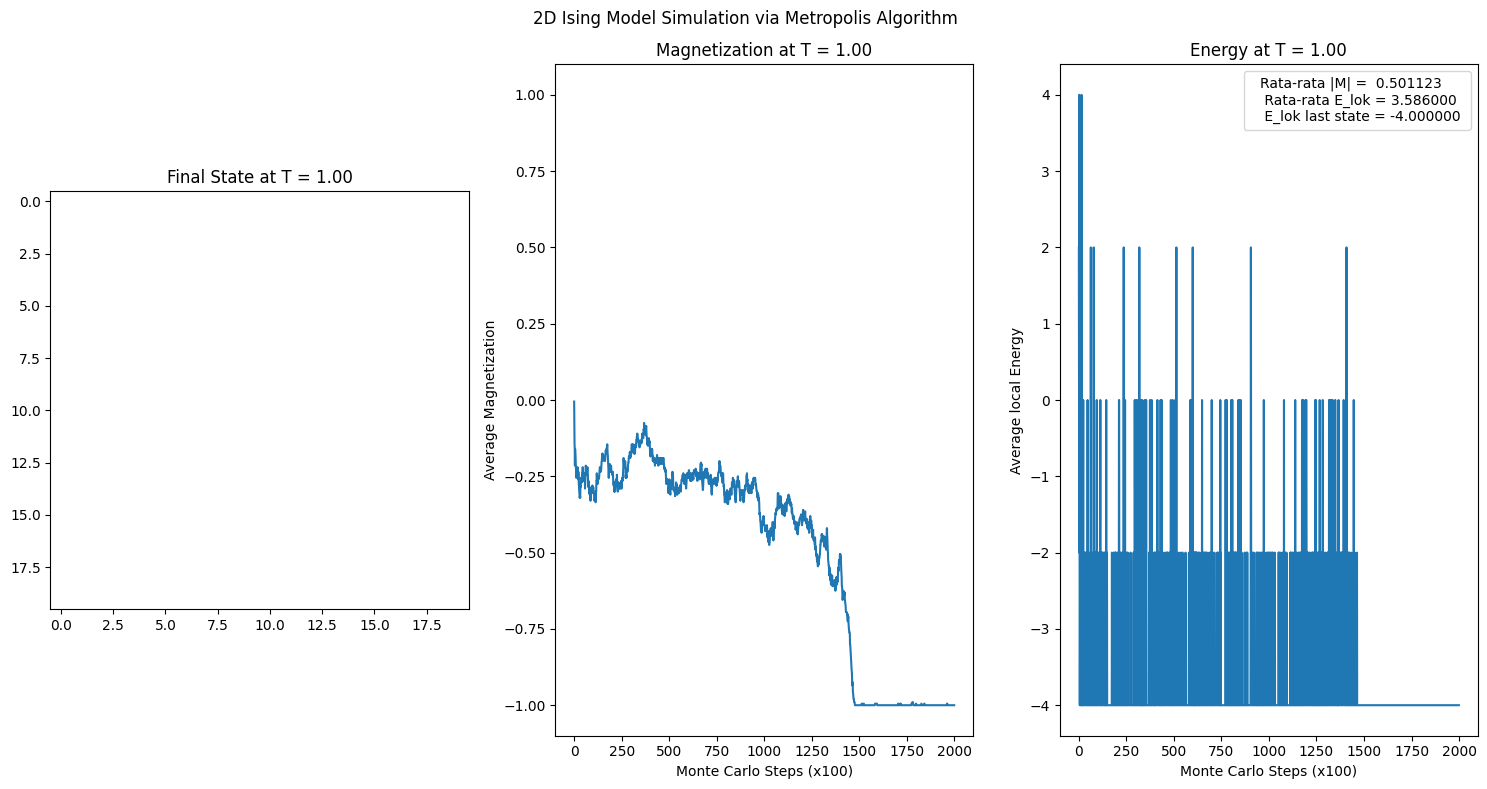

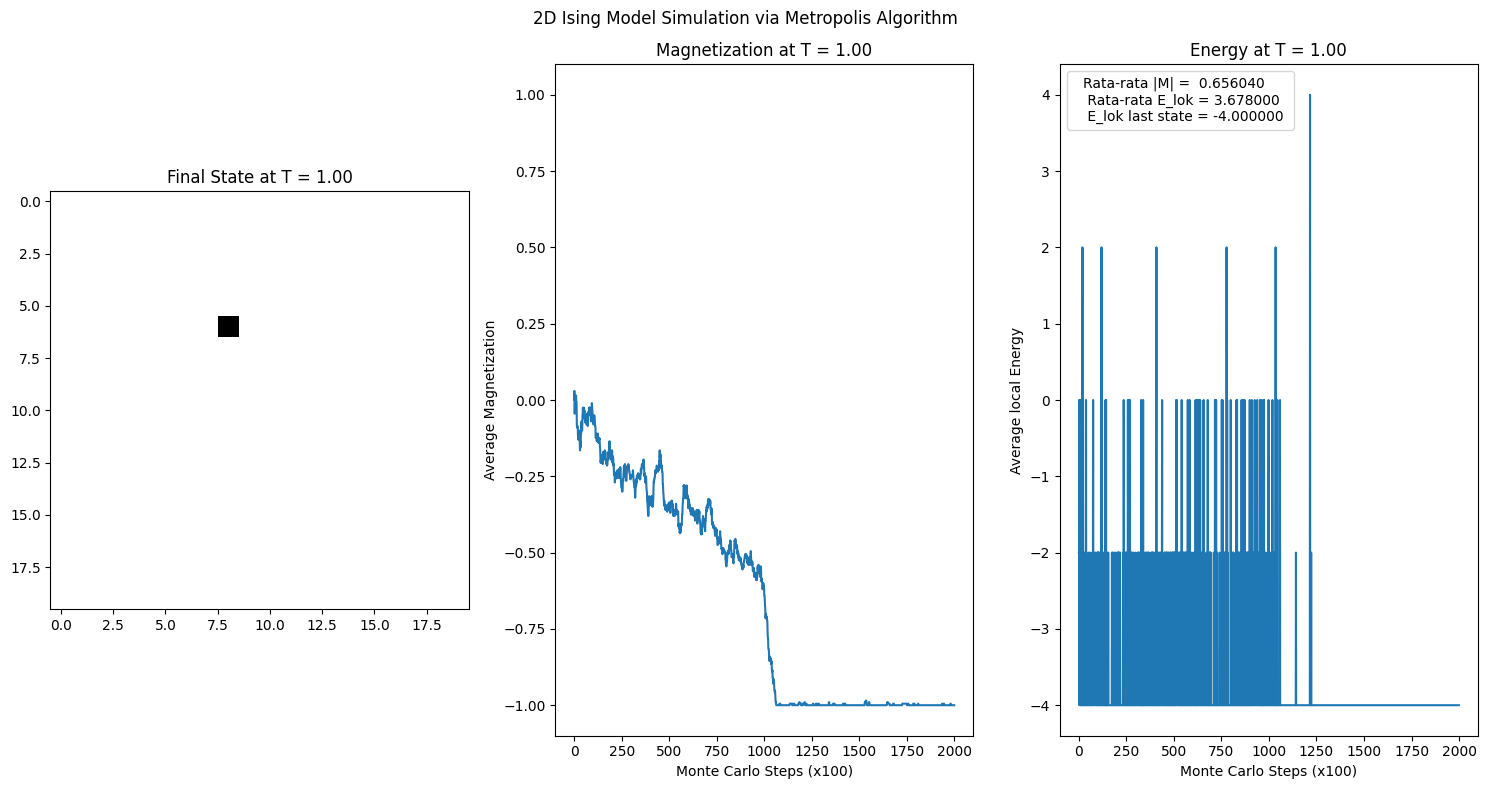

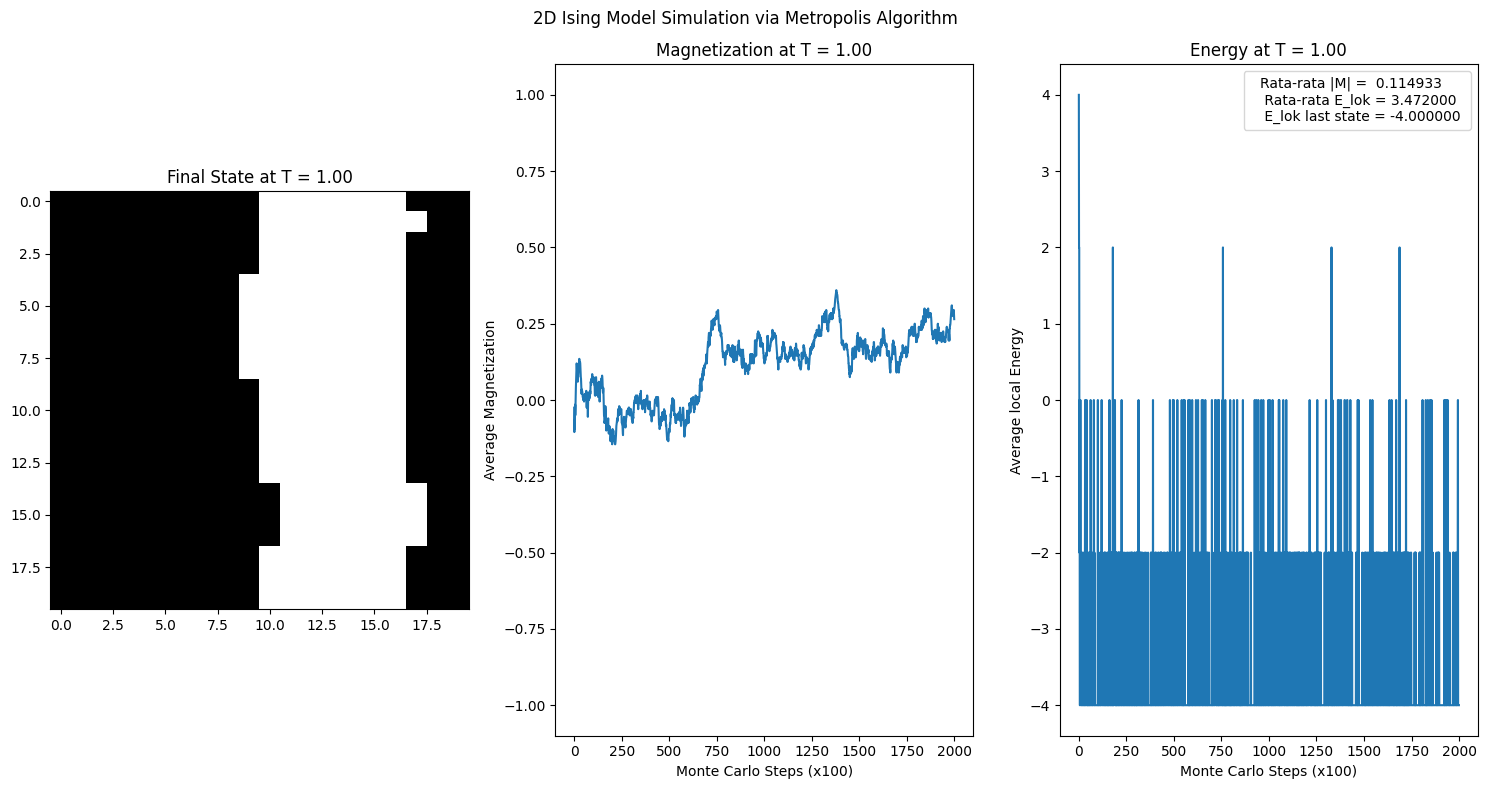

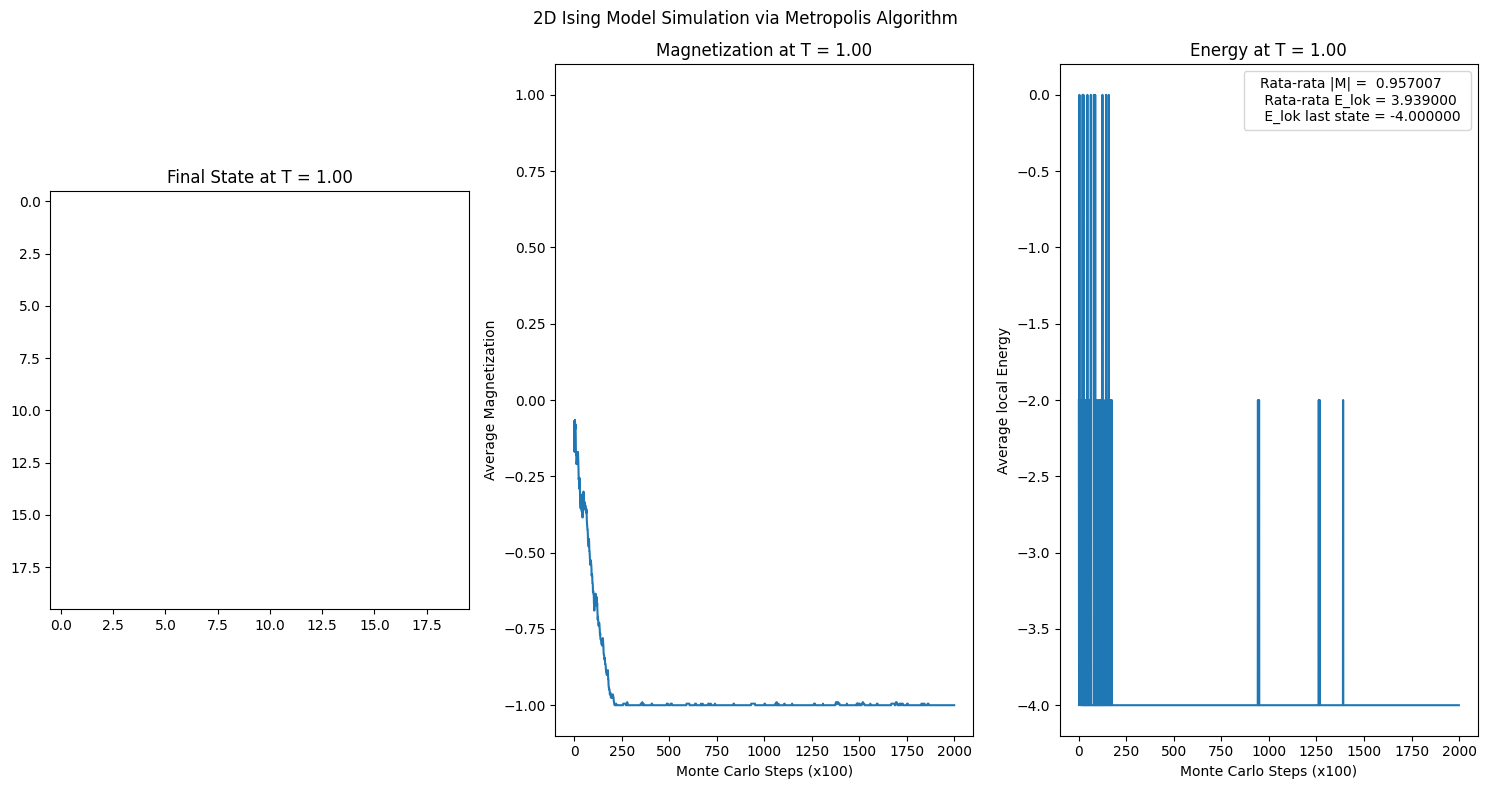

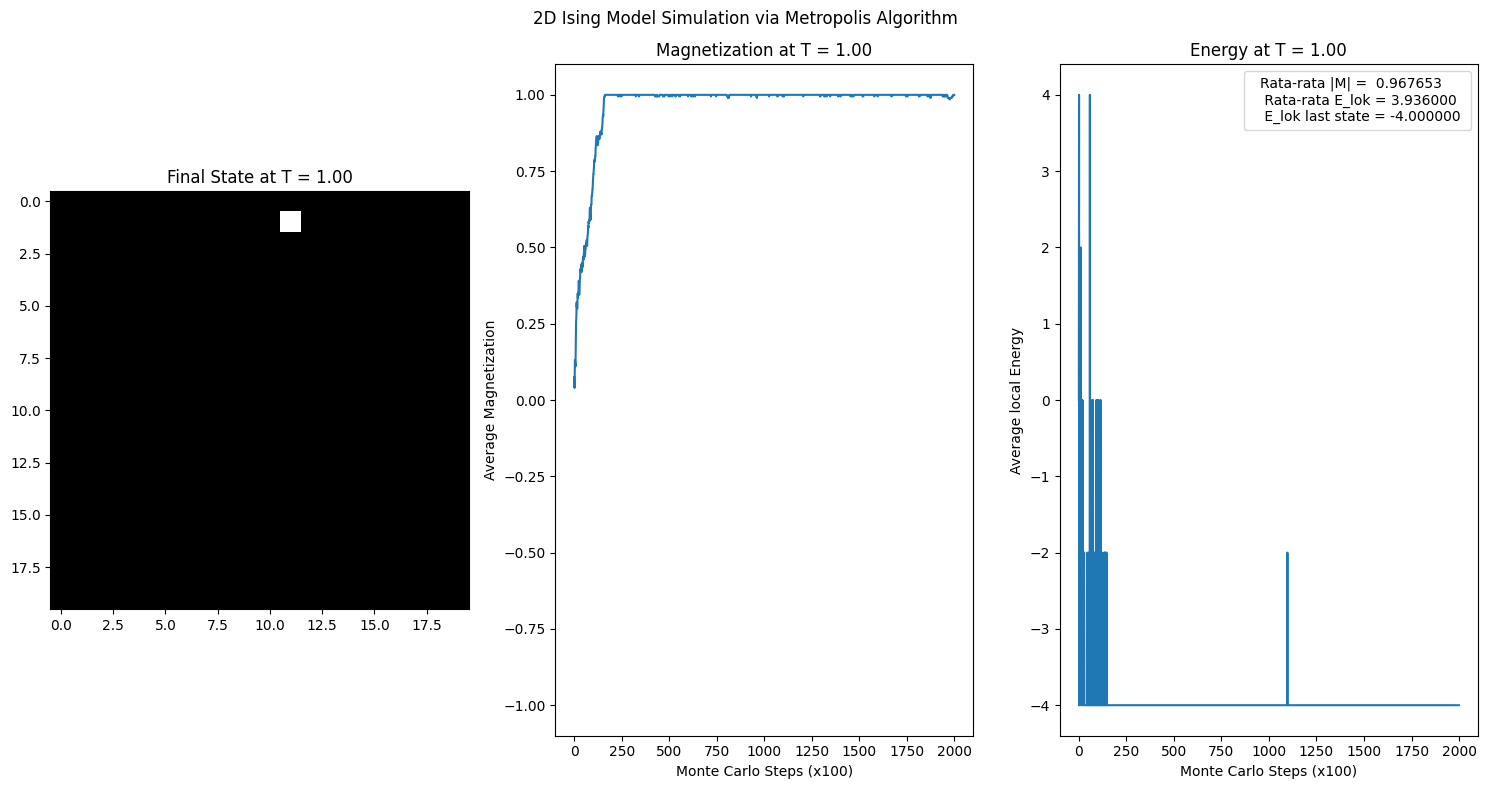

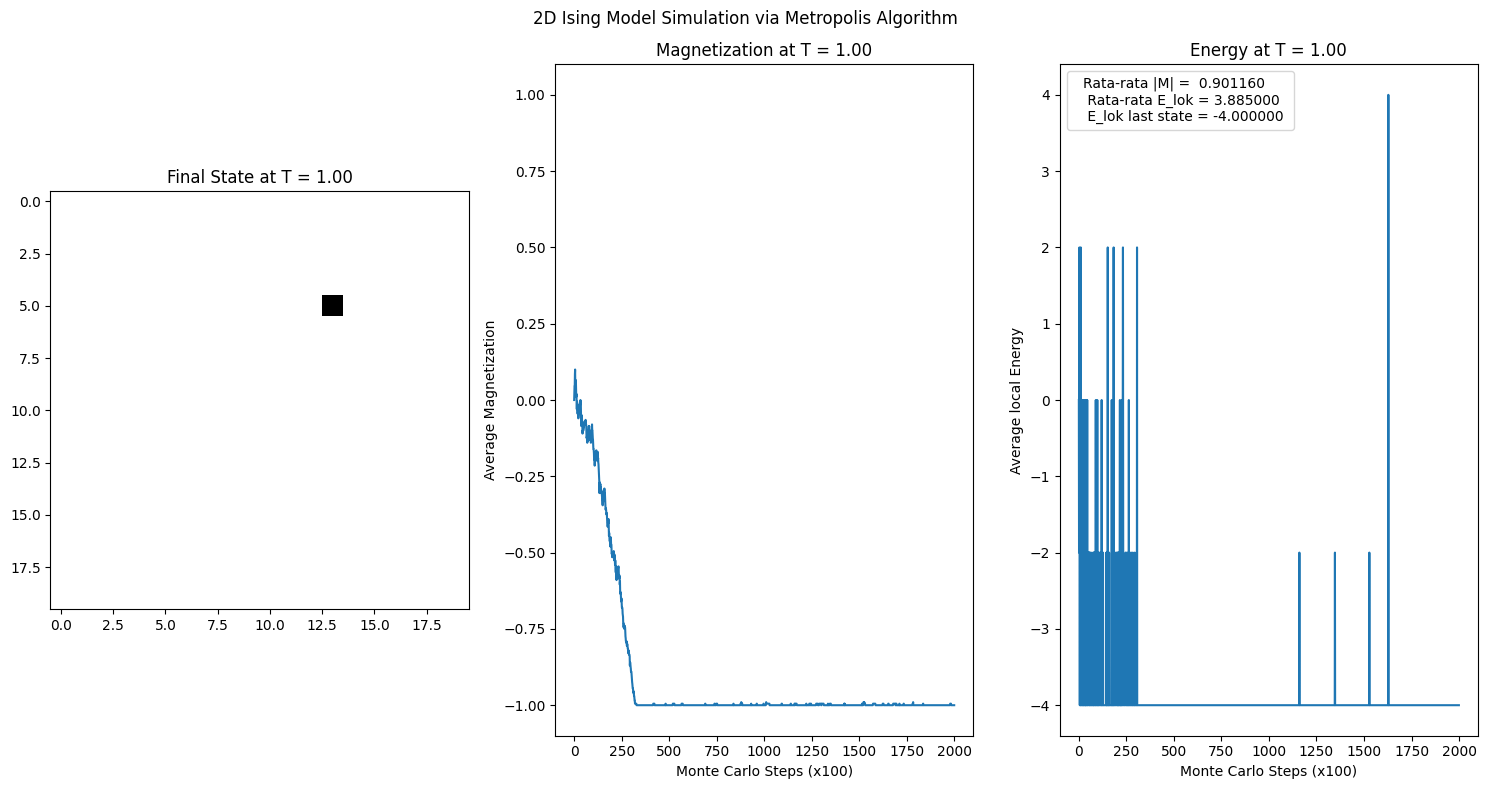

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random


def metropolis_step(grid, T):
    N = grid.shape[0]
    x, y = random.randint(0, N-1), random.randint(0, N-1)
    s_neighbors = (
        grid[(x+1)%N, y] + grid[(x-1)%N, y] +
        grid[x, (y+1)%N] + grid[x, (y-1)%N]
    )
    delta_E = 2 * grid[x, y] * s_neighbors
    if delta_E < 0 or random.random() < np.exp(-delta_E /T):
        grid[x, y] *= -1
    E_lok = -(delta_E/2)
    return grid, E_lok

def run_simulation(N=20, temp=1.0, n_steps=100000):
    grid = np.random.choice([-1, 1], size=(N, N))
    magnetization_history = []
    Elok_history = []
    for step in range(n_steps):
        grid, E_lok = metropolis_step(grid, temp)
        if step % 100 == 0:
            magnetization = np.mean(grid)
            magnetization_history.append(magnetization)
            elok = np.mean(E_lok)
            Elok_history.append(elok)
    return grid, magnetization_history, Elok_history

def plot(grid_size,temperatures,monte_carlo_steps):
    fig, axes = plt.subplots(1, 3, figsize=(15, 8))
    fig.suptitle('2D Ising Model Simulation via Metropolis Algorithm')
    final_grid, M_history, E_history = run_simulation(N=grid_size, temp=temperatures, n_steps=monte_carlo_steps)

    ax_grid = axes[0]
    ax_grid.imshow(final_grid, cmap='binary', vmin=-1, vmax=1)
    ax_grid.set_title(f"Final State at T = {temperatures:.2f}")

    ax_mag = axes[1]
    ax_mag.plot(M_history)
    ax_mag.set_title(f"Magnetization at T = {temperatures:.2f}")
    ax_mag.set_xlabel("Monte Carlo Steps (x100)")
    ax_mag.set_ylabel("Average Magnetization")
    ax_mag.set_ylim(-1.1, 1.1)

    ax_e = axes[2]
    ax_e.plot(E_history)
    ax_e.set_title(f"Energy at T = {temperatures:.2f}")
    ax_e.set_xlabel("Monte Carlo Steps (x100)")
    ax_e.set_ylabel("Average local Energy")
    teks_legenda = mpatches.Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='none')
    plt.legend([teks_legenda], [f'Rata-rata |M| =  {abs(np.mean(M_history)):.6f}\n Rata-rata E_lok = {abs(np.mean(E_history)):.6f}\n E_lok last state = {E_history[-1]:.6f} '], handlelength=0)
    plt.tight_layout()
    plt.show()
    return M_history, E_history

if __name__ == "__main__":
    grid_size = 20
    temperatures = 1.0
    monte_carlo_steps = 200000
    for i in range (6):
      datam, dataE = plot(grid_size,temperatures,monte_carlo_steps)